In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from my_functions import *

sns.set_theme()
gc.enable()

In [3]:
card_data=pd.read_csv("credit_card_balance.csv")
card_data.shape

(3840312, 23)

In [4]:
card_data.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [5]:
card_data.isnull().sum()

SK_ID_PREV                         0
SK_ID_CURR                         0
MONTHS_BALANCE                     0
AMT_BALANCE                        0
AMT_CREDIT_LIMIT_ACTUAL            0
AMT_DRAWINGS_ATM_CURRENT      749816
AMT_DRAWINGS_CURRENT               0
AMT_DRAWINGS_OTHER_CURRENT    749816
AMT_DRAWINGS_POS_CURRENT      749816
AMT_INST_MIN_REGULARITY       305236
AMT_PAYMENT_CURRENT           767988
AMT_PAYMENT_TOTAL_CURRENT          0
AMT_RECEIVABLE_PRINCIPAL           0
AMT_RECIVABLE                      0
AMT_TOTAL_RECEIVABLE               0
CNT_DRAWINGS_ATM_CURRENT      749816
CNT_DRAWINGS_CURRENT               0
CNT_DRAWINGS_OTHER_CURRENT    749816
CNT_DRAWINGS_POS_CURRENT      749816
CNT_INSTALMENT_MATURE_CUM     305236
NAME_CONTRACT_STATUS               0
SK_DPD                             0
SK_DPD_DEF                         0
dtype: int64

In [6]:
card_data.describe()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,SK_DPD,SK_DPD_DEF
count,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,...,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,3.840312e+06,3.840312e+06
mean,1.904504e+06,2.783242e+05,-3.452192e+01,5.830016e+04,1.538080e+05,5.961325e+03,7.433388e+03,2.881696e+02,2.968805e+03,3.540204e+03,...,5.596588e+04,5.808881e+04,5.809829e+04,3.094490e-01,7.031439e-01,4.812496e-03,5.594791e-01,2.082508e+01,9.283667e+00,3.316220e-01
std,5.364695e+05,1.027045e+05,2.666775e+01,1.063070e+05,1.651457e+05,2.822569e+04,3.384608e+04,8.201989e+03,2.079689e+04,5.600154e+03,...,1.025336e+05,1.059654e+05,1.059718e+05,1.100401e+00,3.190347e+00,8.263861e-02,3.240649e+00,2.005149e+01,9.751570e+01,2.147923e+01
min,1.000018e+06,1.000060e+05,-9.600000e+01,-4.202502e+05,0.000000e+00,-6.827310e+03,-6.211620e+03,0.000000e+00,0.000000e+00,0.000000e+00,...,-4.233058e+05,-4.202502e+05,-4.202502e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.434385e+06,1.895170e+05,-5.500000e+01,0.000000e+00,4.500000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00
50%,1.897122e+06,2.783960e+05,-2.800000e+01,0.000000e+00,1.125000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,0.000000e+00
75%,2.369328e+06,3.675800e+05,-1.100000e+01,8.904669e+04,1.800000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.633911e+03,...,8.535924e+04,8.889949e+04,8.891451e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00
max,2.843496e+06,4.562500e+05,-1.000000e+00,1.505902e+06,1.350000e+06,2.115000e+06,2.287098e+06,1.529847e+06,2.239274e+06,2.028820e+05,...,1.472317e+06,1.493338e+06,1.493338e+06,5.100000e+01,1.650000e+02,1.200000e+01,1.650000e+02,1.200000e+02,3.260000e+03,3.260000e+03


### Aggregation

In [7]:
card_data.drop(labels=['MONTHS_BALANCE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF', 'SK_ID_PREV'],
               axis=1, inplace=True)

In [8]:
agg_data=card_data.groupby(by='SK_ID_CURR').agg(func=['min', 'max', 'median', 'sum'])
agg_data.columns=pd.Index(['_'.join(val) for val in agg_data.columns.to_flat_index()])
agg_data.reset_index(inplace=True)
agg_data.shape

(103558, 69)

In [9]:
'''
adding target column
<main_data_id_target> contains target for each current loan
'''
main_data_id_target=pd.read_csv('application_train.csv',usecols=['SK_ID_CURR', 'TARGET']) 
agg_target=pd.merge(left=agg_data, right=main_data_id_target, on='SK_ID_CURR')
agg_target.shape

(86905, 70)

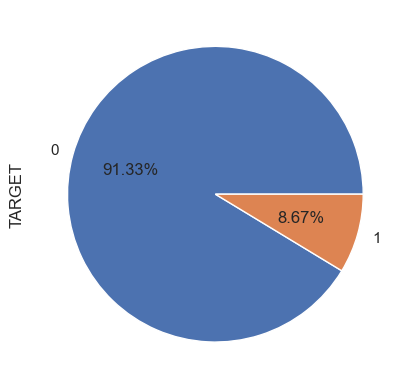

In [10]:
'''
distribution of target in the aggregated data
'''
agg_target['TARGET'].value_counts().plot.pie(autopct='%1.2f%%');

## Analysis

In [11]:
# plot_all_numeric_kde(agg_target, agg_target.columns)

In [12]:
numerical_features=pd.Index(['AMT_BALANCE_max', 'AMT_DRAWINGS_ATM_CURRENT_max',
                             'AMT_DRAWINGS_CURRENT_max', 'AMT_INST_MIN_REGULARITY_max',
                             'AMT_PAYMENT_CURRENT_median', 'AMT_RECEIVABLE_PRINCIPAL_max',
                             'AMT_TOTAL_RECEIVABLE_max', 'AMT_RECIVABLE_max',
                             'CNT_DRAWINGS_ATM_CURRENT_max', 'CNT_DRAWINGS_CURRENT_max',
                             'CNT_INSTALMENT_MATURE_CUM_max', 'SK_ID_CURR', 'TARGET'])
numerical_frame=agg_target[numerical_features].copy()
numerical_frame.shape, numerical_frame.columns.sort_values()

((86905, 13),
 Index(['AMT_BALANCE_max', 'AMT_DRAWINGS_ATM_CURRENT_max',
        'AMT_DRAWINGS_CURRENT_max', 'AMT_INST_MIN_REGULARITY_max',
        'AMT_PAYMENT_CURRENT_median', 'AMT_RECEIVABLE_PRINCIPAL_max',
        'AMT_RECIVABLE_max', 'AMT_TOTAL_RECEIVABLE_max',
        'CNT_DRAWINGS_ATM_CURRENT_max', 'CNT_DRAWINGS_CURRENT_max',
        'CNT_INSTALMENT_MATURE_CUM_max', 'SK_ID_CURR', 'TARGET'],
       dtype='object'))

### AMT_BALANCE_max

In [13]:
numerical_frame['AMT_BALANCE_max'].isnull().sum()

0

In [14]:
numerical_frame['AMT_BALANCE_max'].describe()

count    8.690500e+04
mean     1.445013e+05
std      1.728090e+05
min      0.000000e+00
25%      0.000000e+00
50%      9.742432e+04
75%      1.951825e+05
max      1.354829e+06
Name: AMT_BALANCE_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

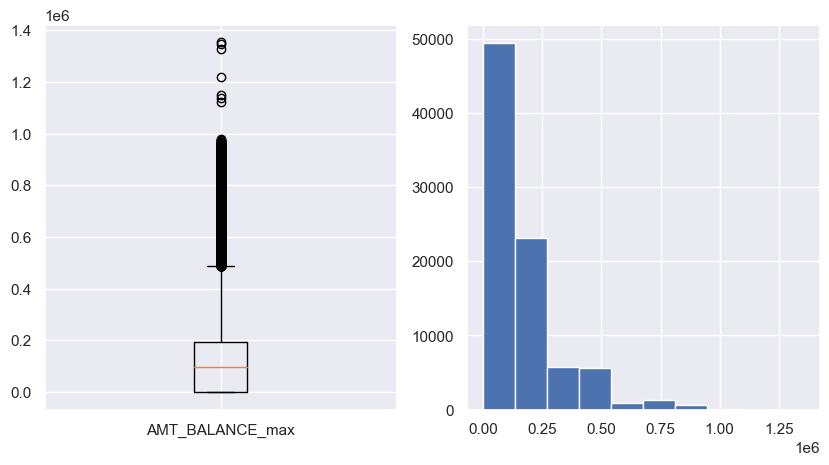

In [15]:
plot_hist_box(numerical_frame, 'AMT_BALANCE_max')

Number of outliers : 7


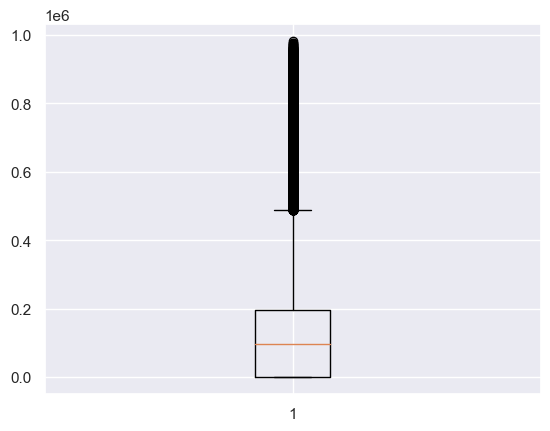

In [18]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[numerical_frame['AMT_BALANCE_max']<1e6, 'AMT_BALANCE_max']);
numerical_frame['AMT_BALANCE_max_outlier']=0
numerical_frame.loc[numerical_frame['AMT_BALANCE_max']>=1e6, 'AMT_BALANCE_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_BALANCE_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_BALANCE_max_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

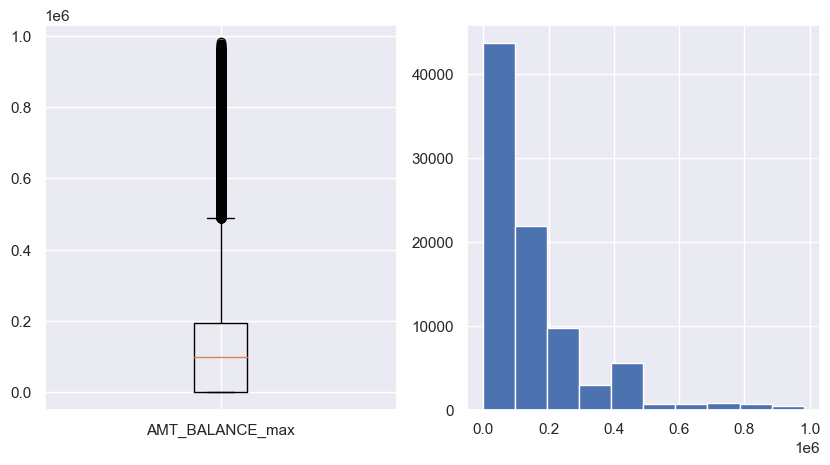

In [19]:
plot_hist_box(good_frame, 'AMT_BALANCE_max')

Median of AMT_BALANCE_max with target=0 : 95221.237500
Median of AMT_BALANCE_max with target=1 : 141802.222500


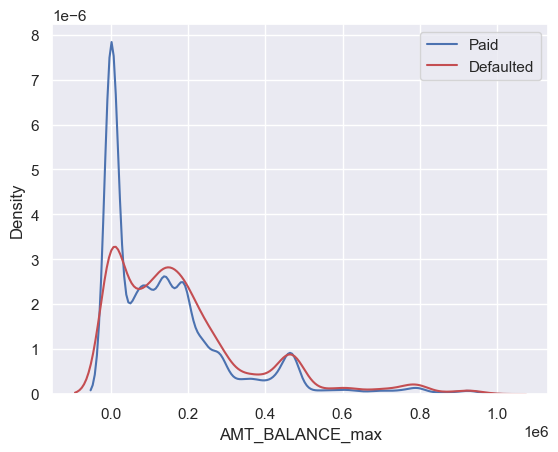

In [20]:
plot_kde_vs_target('AMT_BALANCE_max', good_frame)
median_vs_target('AMT_BALANCE_max', good_frame)

(-0.001, 16570.23]         5.682524
(16570.23, 76093.885]      8.544795
(76093.885, 128433.77]     8.792461
(128433.77, 170798.34]    10.543760
(170798.34, 220171.06]     9.725531
(220171.06, 364689.58]    11.662351
(364689.58, 981683.1]     11.712925
Name: AMT_BALANCE_max_binned, dtype: float64


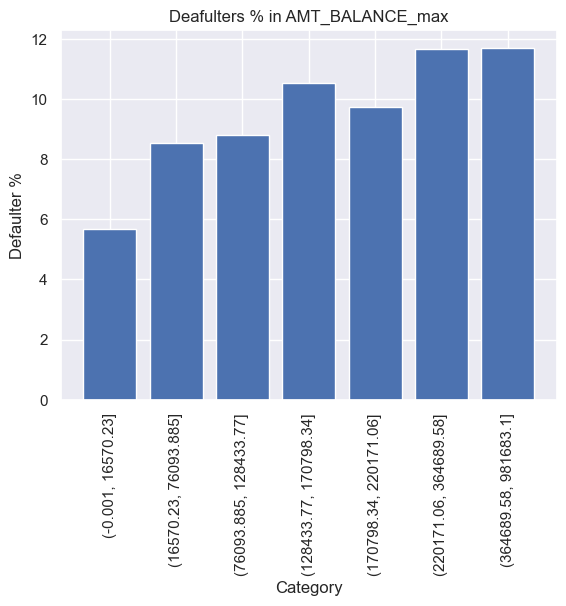

In [21]:
plot_hist_default_pct('AMT_BALANCE_max', good_frame, 9)

### AMT_DRAWINGS_ATM_CURRENT_max

In [22]:
numerical_frame['AMT_DRAWINGS_ATM_CURRENT_max'].isnull().sum()

25765

In [23]:
numerical_frame['AMT_DRAWINGS_ATM_CURRENT_max'].describe()

count    6.114000e+04
mean     1.061446e+05
std      1.075040e+05
min      0.000000e+00
25%      3.150000e+04
50%      9.000000e+04
75%      1.395000e+05
max      2.115000e+06
Name: AMT_DRAWINGS_ATM_CURRENT_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

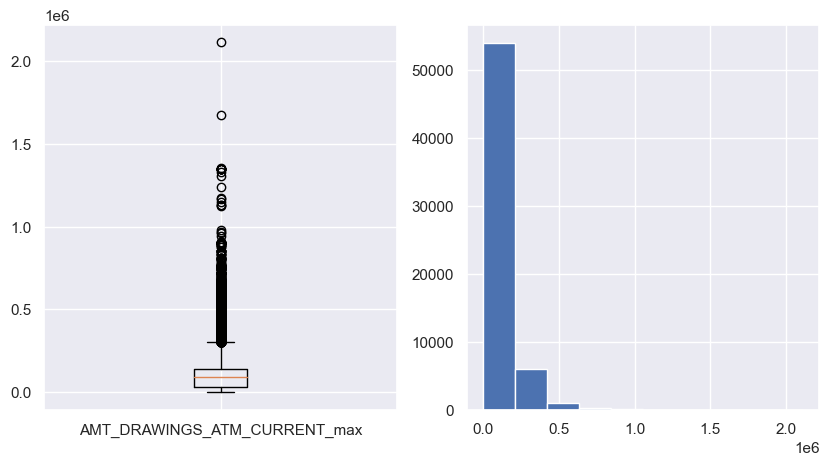

In [24]:
plot_hist_box(numerical_frame, 'AMT_DRAWINGS_ATM_CURRENT_max')

Number of outliers : 160


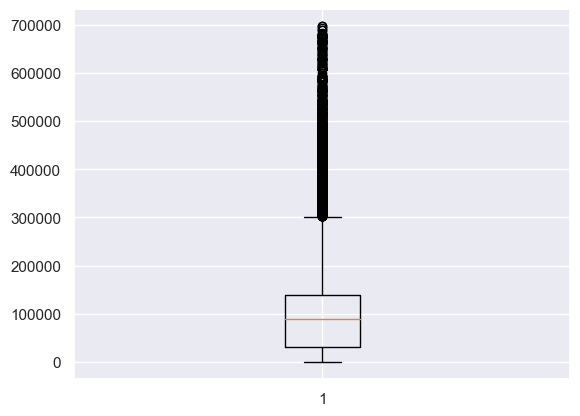

In [34]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[numerical_frame['AMT_DRAWINGS_ATM_CURRENT_max']<0.7e6, 'AMT_DRAWINGS_ATM_CURRENT_max']);
numerical_frame['AMT_DRAWINGS_ATM_CURRENT_max_outlier']=0
numerical_frame.loc[numerical_frame['AMT_DRAWINGS_ATM_CURRENT_max']>=0.7e6, 'AMT_DRAWINGS_ATM_CURRENT_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_DRAWINGS_ATM_CURRENT_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_DRAWINGS_ATM_CURRENT_max_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

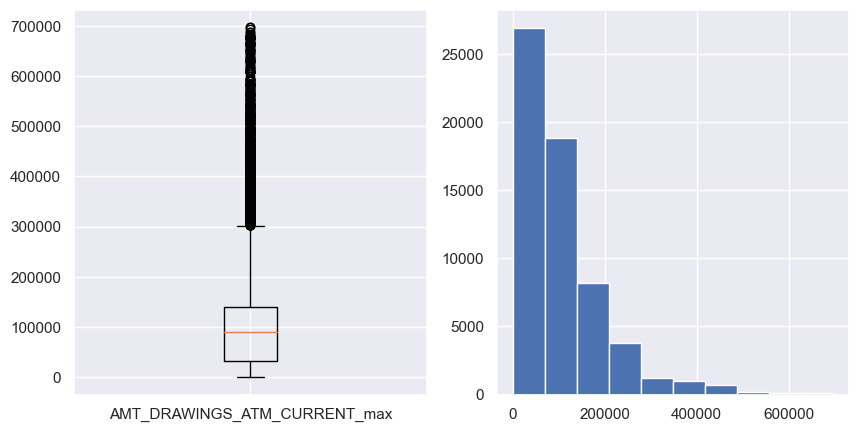

In [35]:
plot_hist_box(good_frame, 'AMT_DRAWINGS_ATM_CURRENT_max')

Median of AMT_DRAWINGS_ATM_CURRENT_max with target=0 : 90000.000000
Median of AMT_DRAWINGS_ATM_CURRENT_max with target=1 : 90000.000000


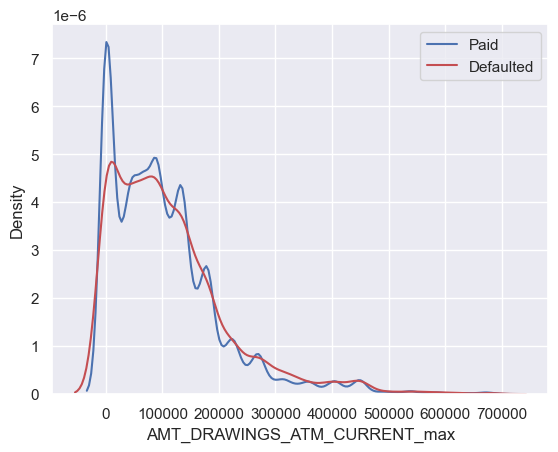

In [36]:
plot_kde_vs_target('AMT_DRAWINGS_ATM_CURRENT_max', good_frame)
median_vs_target('AMT_DRAWINGS_ATM_CURRENT_max', good_frame)

(-0.001, 22500.0]        8.936020
(22500.0, 45000.0]      10.700236
(45000.0, 72000.0]       9.246189
(72000.0, 90000.0]       9.815951
(90000.0, 130500.0]     10.355330
(130500.0, 157500.0]     9.983656
(157500.0, 218250.0]    10.888631
(218250.0, 697500.0]    11.776890
Name: AMT_DRAWINGS_ATM_CURRENT_max_binned, dtype: float64


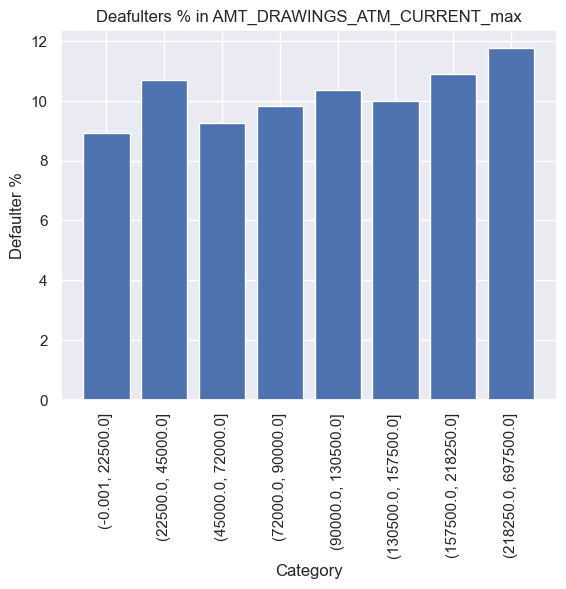

In [37]:
plot_hist_default_pct('AMT_DRAWINGS_ATM_CURRENT_max', good_frame, 9)

### AMT_DRAWINGS_CURRENT_max

In [38]:
numerical_frame['AMT_DRAWINGS_CURRENT_max'].isnull().sum()

0

In [39]:
numerical_frame['AMT_DRAWINGS_CURRENT_max'].describe()

count    8.690500e+04
mean     9.984999e+04
std      1.223621e+05
min      0.000000e+00
25%      0.000000e+00
50%      6.961131e+04
75%      1.400045e+05
max      2.115000e+06
Name: AMT_DRAWINGS_CURRENT_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

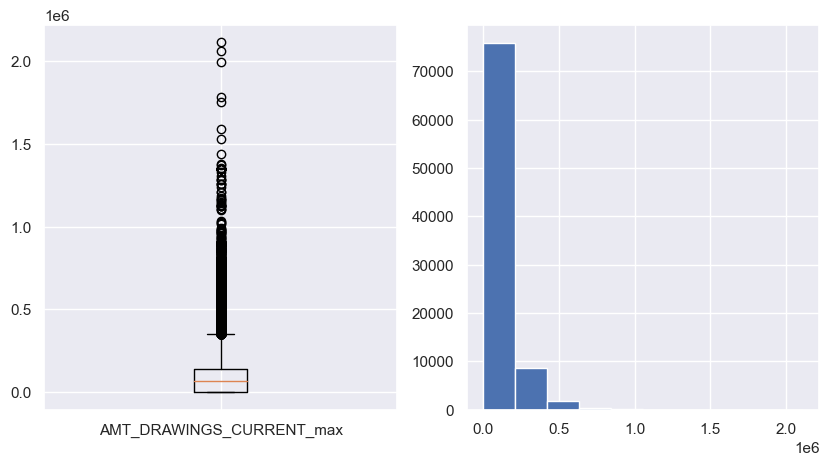

In [40]:
plot_hist_box(numerical_frame, 'AMT_DRAWINGS_CURRENT_max')

Number of outliers : 195


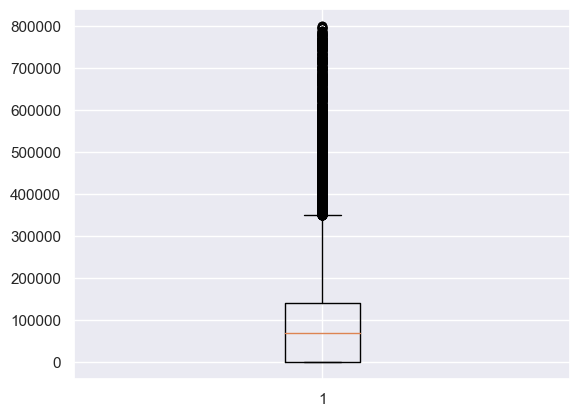

In [43]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[numerical_frame['AMT_DRAWINGS_CURRENT_max']<0.8e6, 'AMT_DRAWINGS_CURRENT_max']);
numerical_frame['AMT_DRAWINGS_CURRENT_max_outlier']=0
numerical_frame.loc[numerical_frame['AMT_DRAWINGS_CURRENT_max']>=0.8e6, 'AMT_DRAWINGS_CURRENT_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_DRAWINGS_CURRENT_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_DRAWINGS_CURRENT_max_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

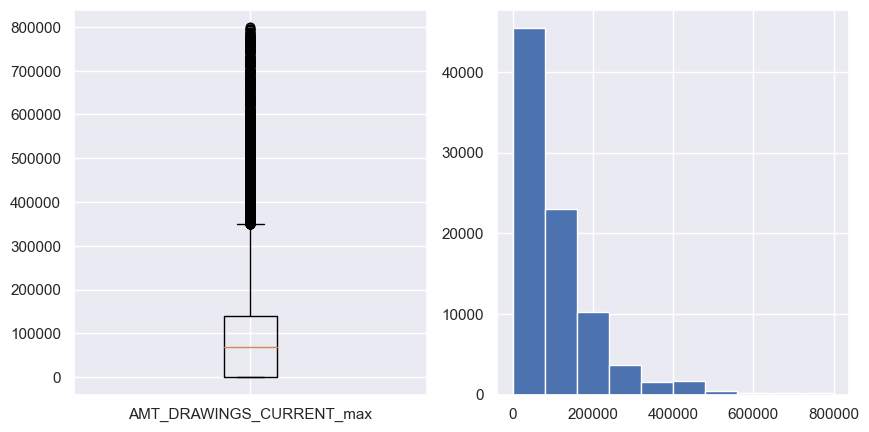

In [44]:
plot_hist_box(good_frame, 'AMT_DRAWINGS_CURRENT_max')

Median of AMT_DRAWINGS_CURRENT_max with target=0 : 67500.000000
Median of AMT_DRAWINGS_CURRENT_max with target=1 : 90000.000000


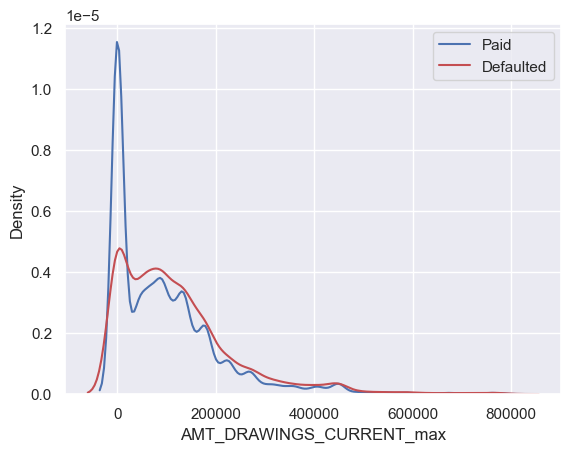

In [45]:
plot_kde_vs_target('AMT_DRAWINGS_CURRENT_max', good_frame)
median_vs_target('AMT_DRAWINGS_CURRENT_max', good_frame)

(-0.001, 14400.0]          5.516359
(14400.0, 56690.88]       10.556941
(56690.88, 90000.0]        9.454284
(90000.0, 118267.65]       9.591685
(118267.65, 157500.0]     10.141578
(157500.0, 225000.0]      10.687732
(225000.0, 799361.595]    11.238117
Name: AMT_DRAWINGS_CURRENT_max_binned, dtype: float64


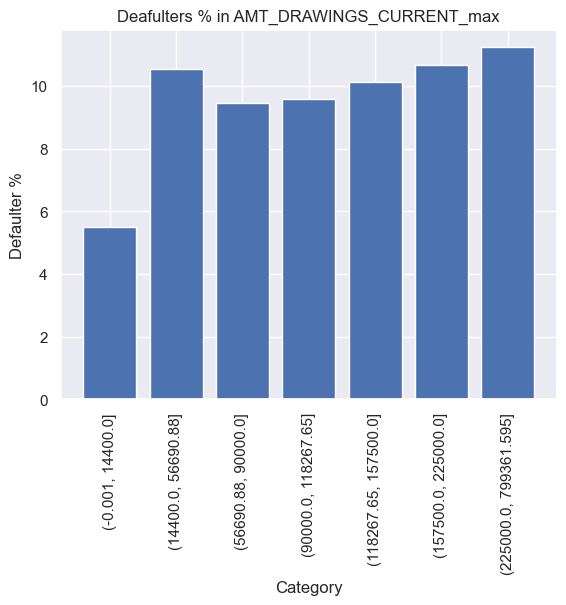

In [46]:
plot_hist_default_pct('AMT_DRAWINGS_CURRENT_max', good_frame, 9)

### AMT_INST_MIN_REGULARITY_max

In [47]:
numerical_frame['AMT_INST_MIN_REGULARITY_max'].isnull().sum()

0

In [48]:
numerical_frame['AMT_INST_MIN_REGULARITY_max'].describe()

count     86905.000000
mean       7245.025964
std        8649.910291
min           0.000000
25%           0.000000
50%        4917.060000
75%        9600.750000
max      202882.005000
Name: AMT_INST_MIN_REGULARITY_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

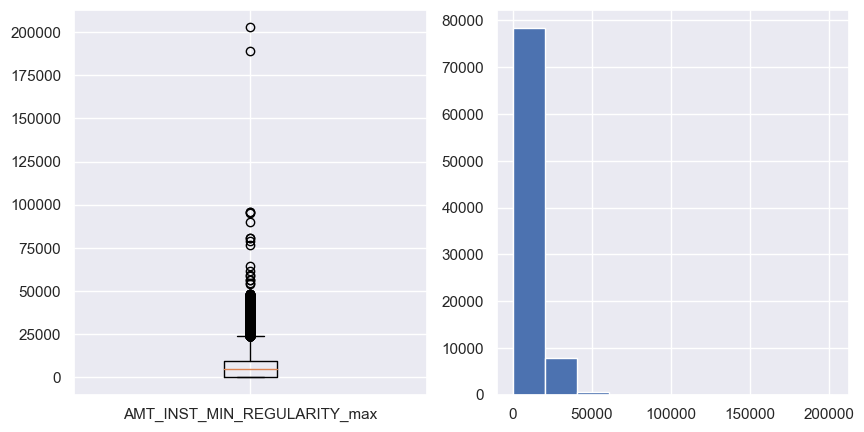

In [49]:
plot_hist_box(numerical_frame, 'AMT_INST_MIN_REGULARITY_max')

Number of outliers : 18


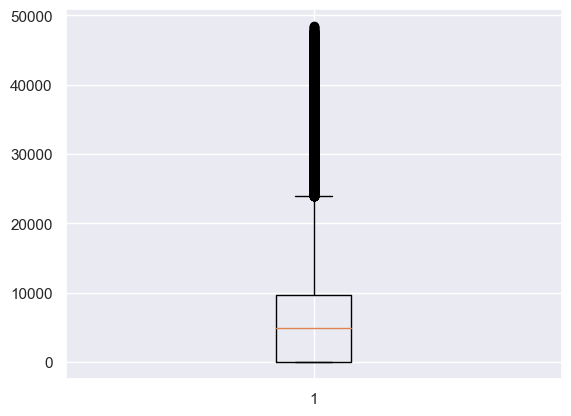

In [53]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[numerical_frame['AMT_INST_MIN_REGULARITY_max']<5e4, 'AMT_INST_MIN_REGULARITY_max']);
numerical_frame['AMT_INST_MIN_REGULARITY_max_outlier']=0
numerical_frame.loc[numerical_frame['AMT_INST_MIN_REGULARITY_max']>=5e4, 'AMT_INST_MIN_REGULARITY_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_INST_MIN_REGULARITY_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_INST_MIN_REGULARITY_max_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

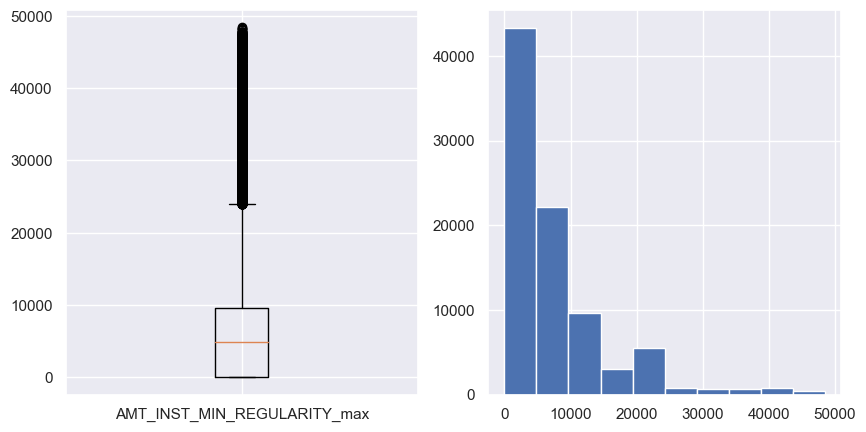

In [54]:
plot_hist_box(good_frame, 'AMT_INST_MIN_REGULARITY_max')

Median of AMT_INST_MIN_REGULARITY_max with target=0 : 4670.662500
Median of AMT_INST_MIN_REGULARITY_max with target=1 : 6984.360000


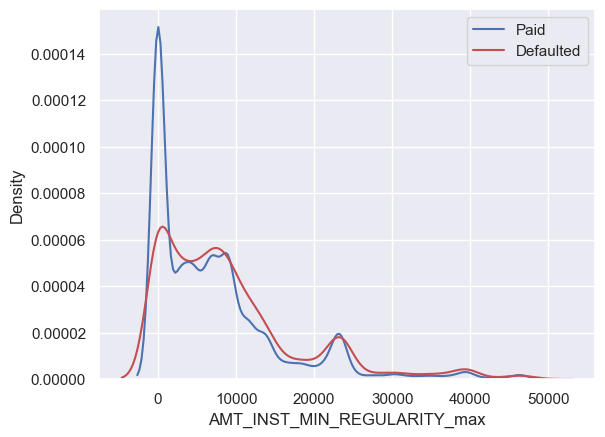

In [55]:
plot_kde_vs_target('AMT_INST_MIN_REGULARITY_max', good_frame)
median_vs_target('AMT_INST_MIN_REGULARITY_max', good_frame)

(-0.001, 2250.0]          5.985186
(2250.0, 4050.0]          9.775185
(4050.0, 6750.0]          8.327969
(6750.0, 8642.52]        11.805661
(8642.52, 10984.455]      9.282088
(10984.455, 18084.24]    11.465562
(18084.24, 48455.73]     11.611767
Name: AMT_INST_MIN_REGULARITY_max_binned, dtype: float64


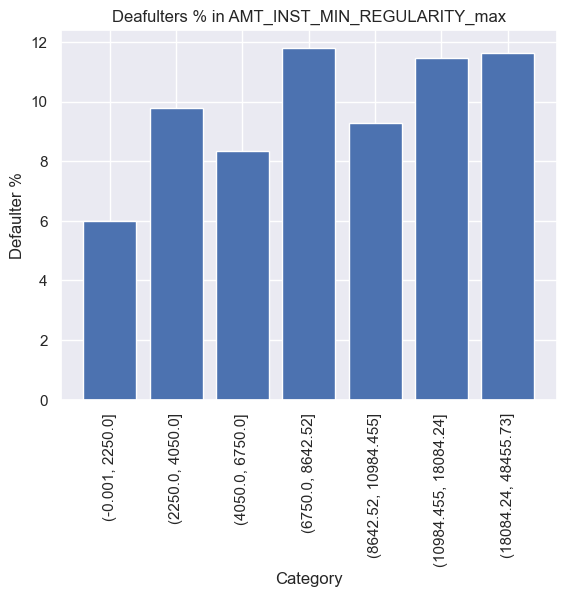

In [56]:
plot_hist_default_pct('AMT_INST_MIN_REGULARITY_max', good_frame, 9)

### AMT_PAYMENT_CURRENT_median

In [57]:
numerical_frame['AMT_PAYMENT_CURRENT_median'].isnull().sum()

25845

In [58]:
numerical_frame['AMT_PAYMENT_CURRENT_median'].describe()

count    6.106000e+04
mean     1.040774e+04
std      2.237263e+04
min      0.000000e+00
25%      4.379287e+02
50%      5.850000e+03
75%      1.242000e+04
max      1.125000e+06
Name: AMT_PAYMENT_CURRENT_median, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

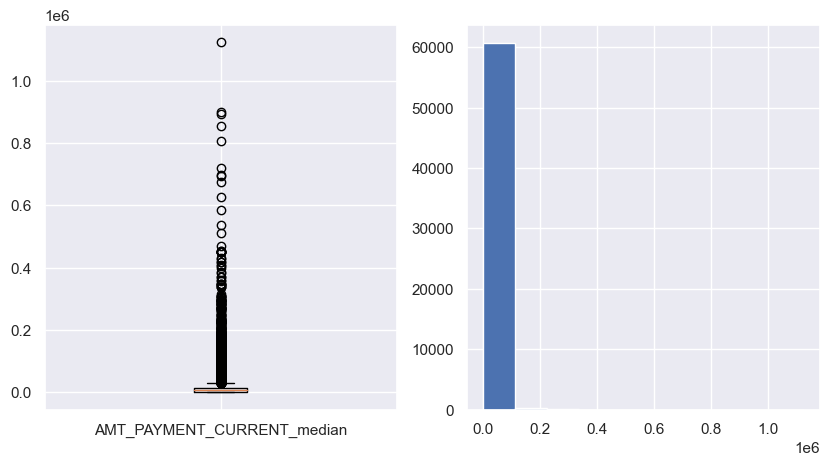

In [59]:
plot_hist_box(numerical_frame, 'AMT_PAYMENT_CURRENT_median')

Number of outliers : 307


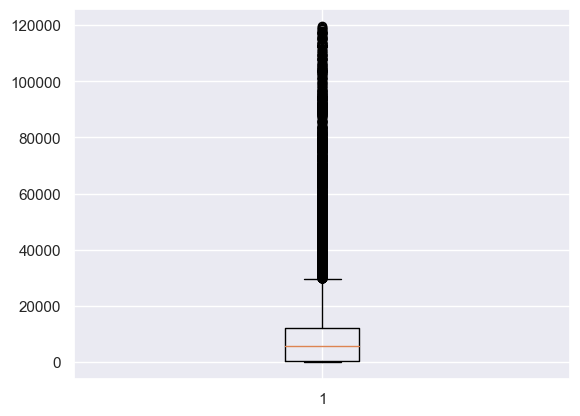

In [70]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[numerical_frame['AMT_PAYMENT_CURRENT_median']<0.12e6, 'AMT_PAYMENT_CURRENT_median']);
numerical_frame['AMT_PAYMENT_CURRENT_median_outlier']=0
numerical_frame.loc[numerical_frame['AMT_PAYMENT_CURRENT_median']>=0.12e6, 'AMT_PAYMENT_CURRENT_median_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_PAYMENT_CURRENT_median_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_PAYMENT_CURRENT_median_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

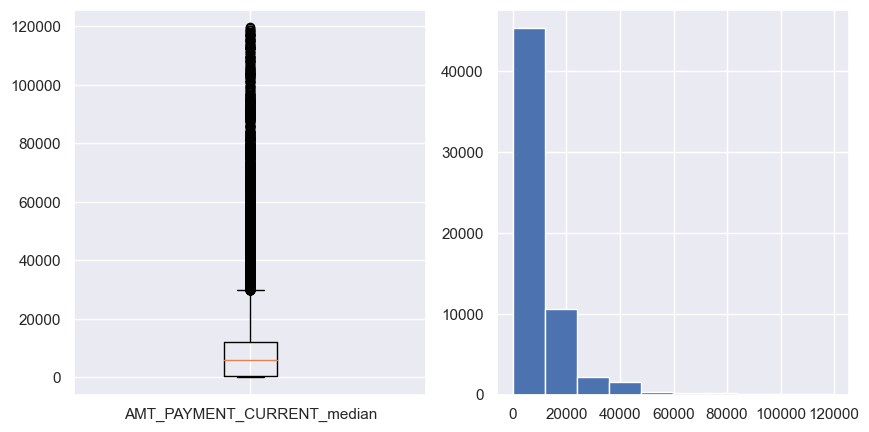

In [71]:
plot_hist_box(good_frame, 'AMT_PAYMENT_CURRENT_median')

Median of AMT_PAYMENT_CURRENT_median with target=0 : 5625.000000
Median of AMT_PAYMENT_CURRENT_median with target=1 : 6750.630000


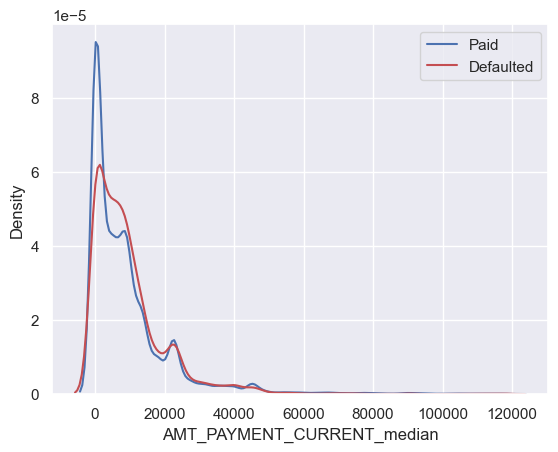

In [72]:
plot_kde_vs_target('AMT_PAYMENT_CURRENT_median', good_frame)
median_vs_target('AMT_PAYMENT_CURRENT_median', good_frame)

(-0.001, 62.695]          8.028440
(62.695, 312.815]         6.340741
(312.815, 2177.43]        7.170370
(2177.43, 4500.0]        11.763104
(4500.0, 6975.0]         12.760500
(6975.0, 9007.515]       10.422915
(9007.515, 13500.0]      12.434896
(13500.0, 22500.0]       10.818020
(22500.0, 119661.795]    10.183754
Name: AMT_PAYMENT_CURRENT_median_binned, dtype: float64


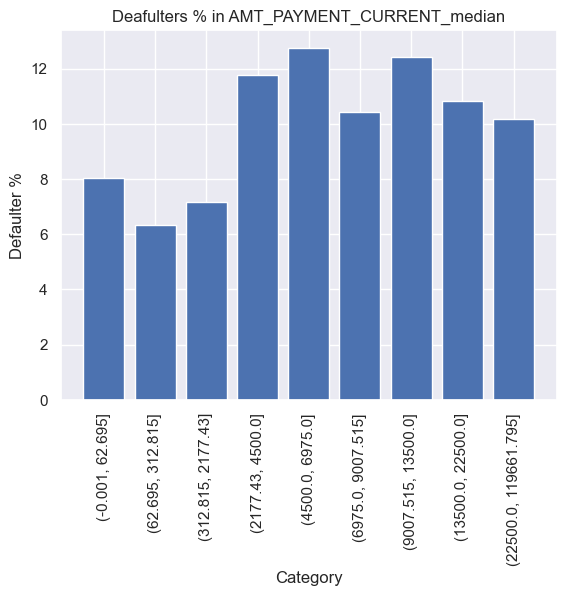

In [73]:
plot_hist_default_pct('AMT_PAYMENT_CURRENT_median', good_frame, 9)

### AMT_RECEIVABLE_PRINCIPAL_max

In [74]:
numerical_frame['AMT_RECEIVABLE_PRINCIPAL_max'].isnull().sum()

0

In [75]:
numerical_frame['AMT_RECEIVABLE_PRINCIPAL_max'].describe()

count    8.690500e+04
mean     1.379477e+05
std      1.660849e+05
min      0.000000e+00
25%      0.000000e+00
50%      9.000000e+04
75%      1.800000e+05
max      1.354829e+06
Name: AMT_RECEIVABLE_PRINCIPAL_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

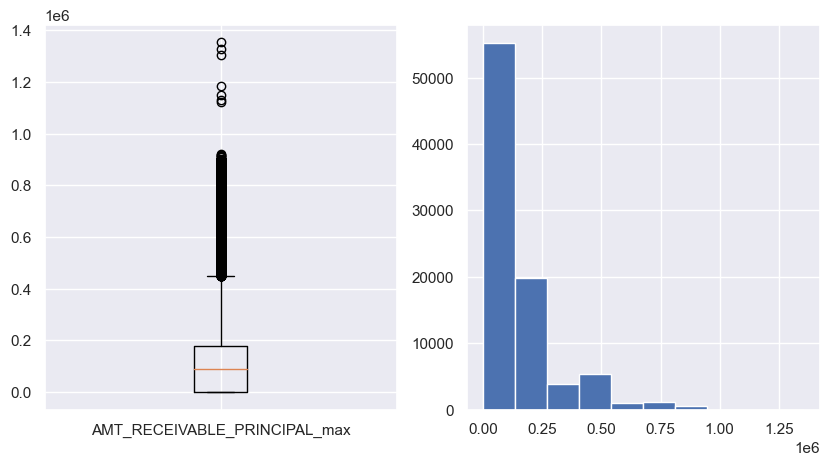

In [76]:
plot_hist_box(numerical_frame, 'AMT_RECEIVABLE_PRINCIPAL_max')

Number of outliers : 7


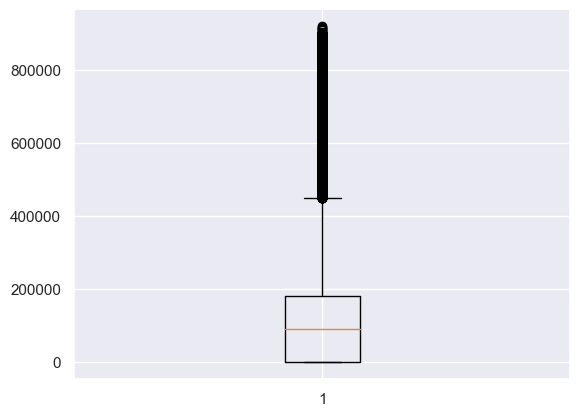

In [79]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[numerical_frame['AMT_RECEIVABLE_PRINCIPAL_max']<1e6, 'AMT_RECEIVABLE_PRINCIPAL_max']);
numerical_frame['AMT_RECEIVABLE_PRINCIPAL_max_outlier']=0
numerical_frame.loc[numerical_frame['AMT_RECEIVABLE_PRINCIPAL_max']>=1e6, 'AMT_RECEIVABLE_PRINCIPAL_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_RECEIVABLE_PRINCIPAL_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_RECEIVABLE_PRINCIPAL_max_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

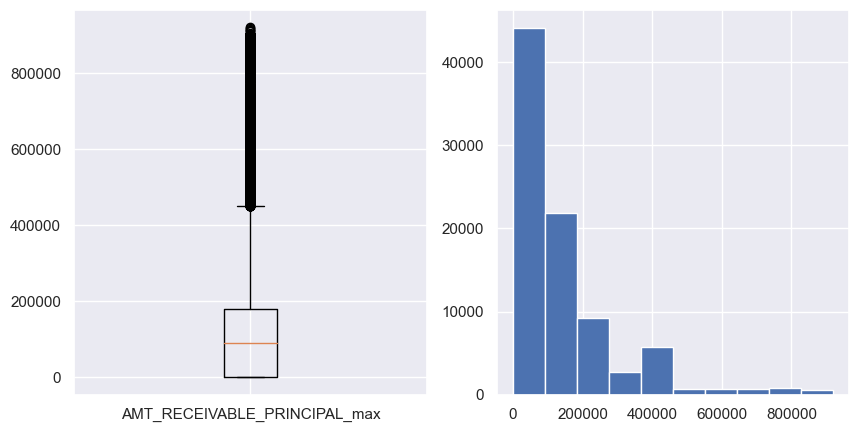

In [80]:
plot_hist_box(good_frame, 'AMT_RECEIVABLE_PRINCIPAL_max')

Median of AMT_RECEIVABLE_PRINCIPAL_max with target=0 : 89985.600000
Median of AMT_RECEIVABLE_PRINCIPAL_max with target=1 : 134802.202500


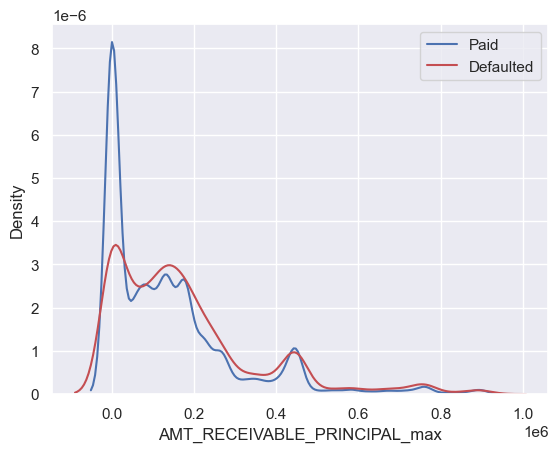

In [81]:
plot_kde_vs_target('AMT_RECEIVABLE_PRINCIPAL_max', good_frame)
median_vs_target('AMT_RECEIVABLE_PRINCIPAL_max', good_frame)

(-0.001, 15681.435]         5.685977
(15681.435, 69900.635]      8.658726
(69900.635, 123150.0]       8.699254
(123150.0, 161563.965]     10.719834
(161563.965, 211607.66]     9.590886
(211607.66, 351271.04]     11.672708
(351271.04, 920412.675]    11.630075
Name: AMT_RECEIVABLE_PRINCIPAL_max_binned, dtype: float64


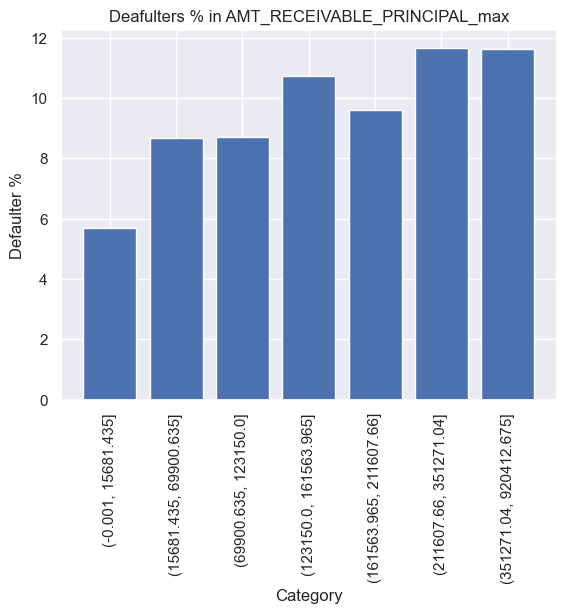

In [82]:
plot_hist_default_pct('AMT_RECEIVABLE_PRINCIPAL_max', good_frame, 9)

### AMT_RECIVABLE_max

In [83]:
numerical_frame['AMT_RECIVABLE_max'].isnull().sum()

0

In [84]:
numerical_frame['AMT_RECIVABLE_max'].describe()

count    8.690500e+04
mean     1.434716e+05
std      1.716723e+05
min      0.000000e+00
25%      0.000000e+00
50%      9.683735e+04
75%      1.944610e+05
max      1.354829e+06
Name: AMT_RECIVABLE_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

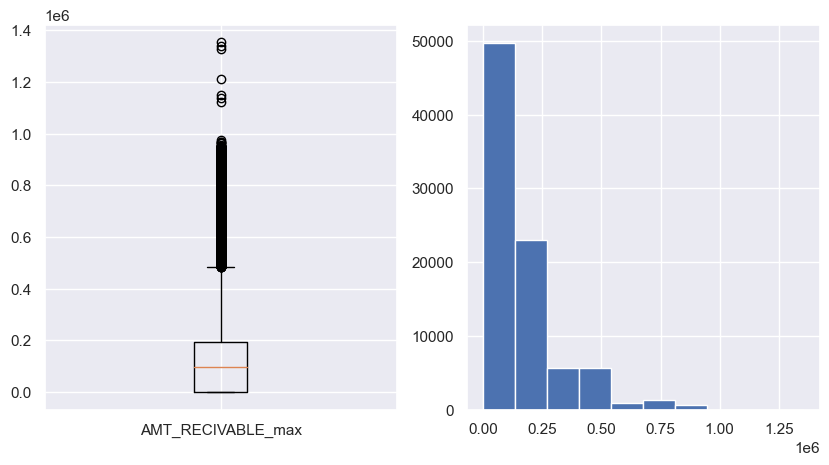

In [85]:
plot_hist_box(numerical_frame, 'AMT_RECIVABLE_max')

Number of outliers : 7


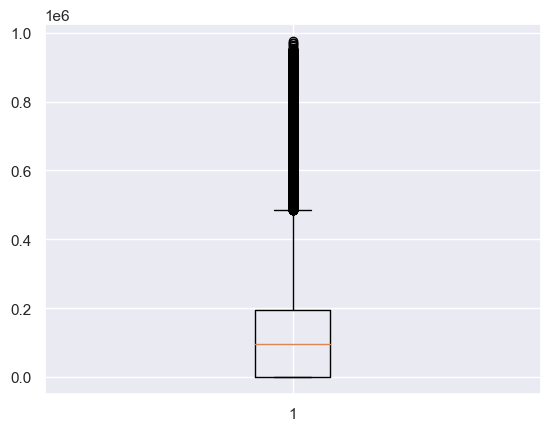

In [88]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[numerical_frame['AMT_RECIVABLE_max']<1e6, 'AMT_RECIVABLE_max']);
numerical_frame['AMT_RECIVABLE_max_outlier']=0
numerical_frame.loc[numerical_frame['AMT_RECIVABLE_max']>=1e6, 'AMT_RECIVABLE_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_RECIVABLE_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_RECIVABLE_max_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

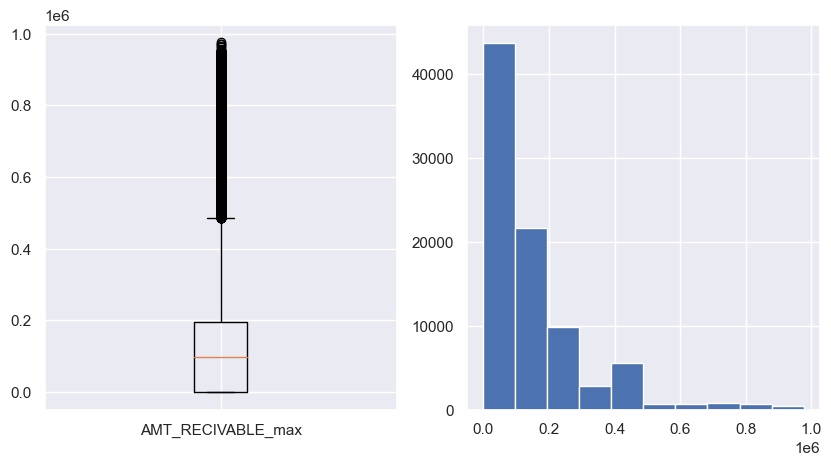

In [89]:
plot_hist_box(good_frame, 'AMT_RECIVABLE_max')

Median of AMT_RECIVABLE_max with target=0 : 94614.322500
Median of AMT_RECIVABLE_max with target=1 : 140040.472500


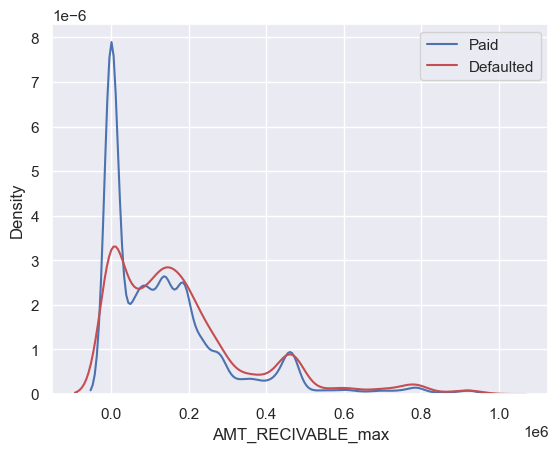

In [90]:
plot_kde_vs_target('AMT_RECIVABLE_max', good_frame)
median_vs_target('AMT_RECIVABLE_max', good_frame)

(-0.001, 16185.36]         5.689429
(16185.36, 75577.28]       8.555153
(75577.28, 127538.6]       8.854598
(127538.6, 169891.515]    10.502330
(169891.515, 218200.6]     9.632315
(218200.6, 361822.255]    11.714138
(361822.255, 976170.6]    11.702568
Name: AMT_RECIVABLE_max_binned, dtype: float64


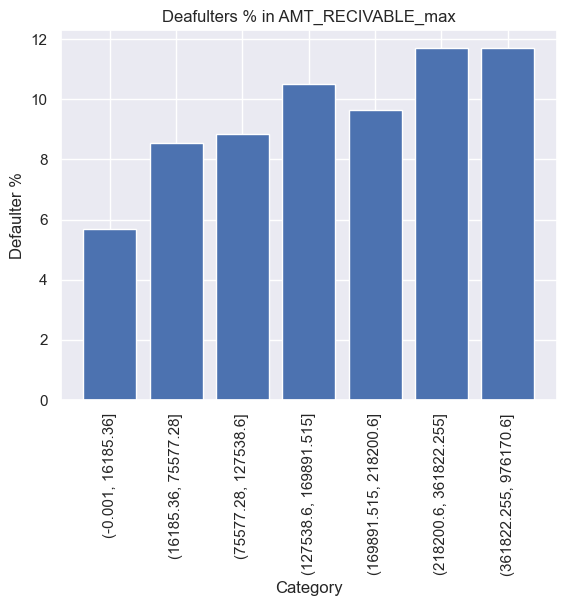

In [91]:
plot_hist_default_pct('AMT_RECIVABLE_max', good_frame, 9)

### AMT_TOTAL_RECEIVABLE_max

In [92]:
numerical_frame['AMT_TOTAL_RECEIVABLE_max'].isnull().sum()

0

In [93]:
numerical_frame['AMT_TOTAL_RECEIVABLE_max'].describe()

count    8.690500e+04
mean     1.434885e+05
std      1.716748e+05
min      0.000000e+00
25%      0.000000e+00
50%      9.686637e+04
75%      1.945033e+05
max      1.354829e+06
Name: AMT_TOTAL_RECEIVABLE_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

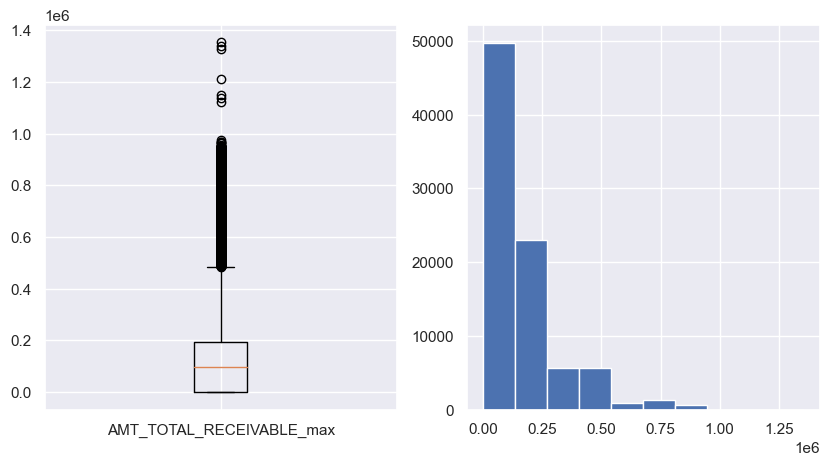

In [94]:
plot_hist_box(numerical_frame, 'AMT_TOTAL_RECEIVABLE_max')

Number of outliers : 7


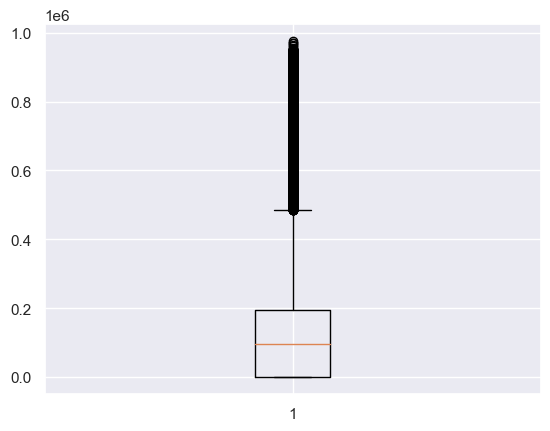

In [96]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[numerical_frame['AMT_TOTAL_RECEIVABLE_max']<1e6, 'AMT_TOTAL_RECEIVABLE_max']);
numerical_frame['AMT_TOTAL_RECEIVABLE_max_outlier']=0
numerical_frame.loc[numerical_frame['AMT_TOTAL_RECEIVABLE_max']>=1e6, 'AMT_TOTAL_RECEIVABLE_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_TOTAL_RECEIVABLE_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_TOTAL_RECEIVABLE_max_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

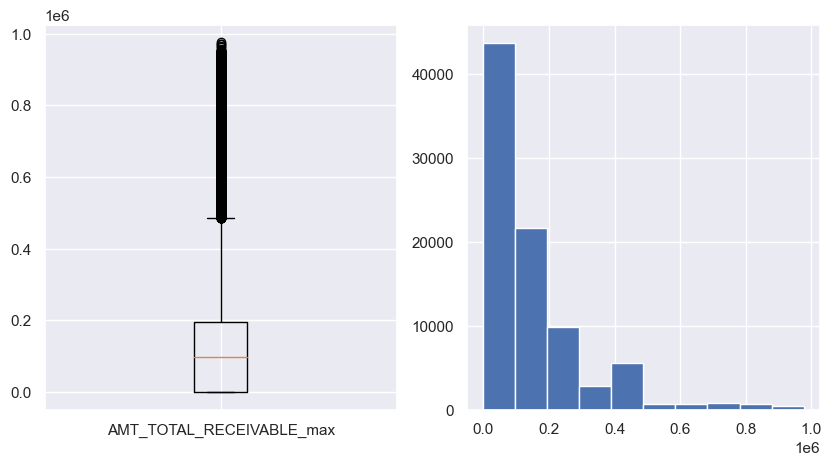

In [97]:
plot_hist_box(good_frame, 'AMT_TOTAL_RECEIVABLE_max')

Median of AMT_TOTAL_RECEIVABLE_max with target=0 : 94649.580000
Median of AMT_TOTAL_RECEIVABLE_max with target=1 : 140040.472500


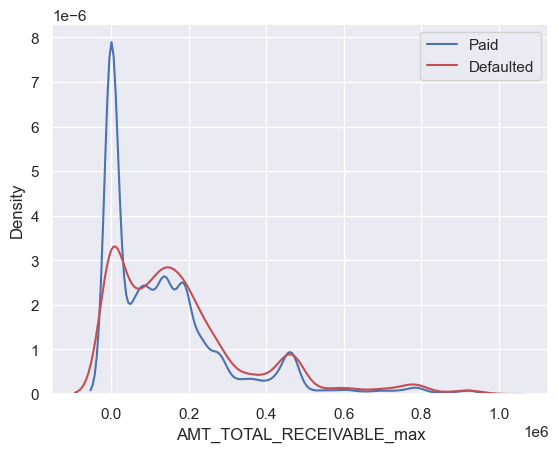

In [98]:
plot_kde_vs_target('AMT_TOTAL_RECEIVABLE_max', good_frame)
median_vs_target('AMT_TOTAL_RECEIVABLE_max', good_frame)

(-0.001, 16185.36]          5.689429
(16185.36, 75720.63]        8.544795
(75720.63, 127564.225]      8.864954
(127564.225, 169897.11]    10.491973
(169897.11, 218200.6]       9.642672
(218200.6, 361822.255]     11.714138
(361822.255, 976170.6]     11.702568
Name: AMT_TOTAL_RECEIVABLE_max_binned, dtype: float64


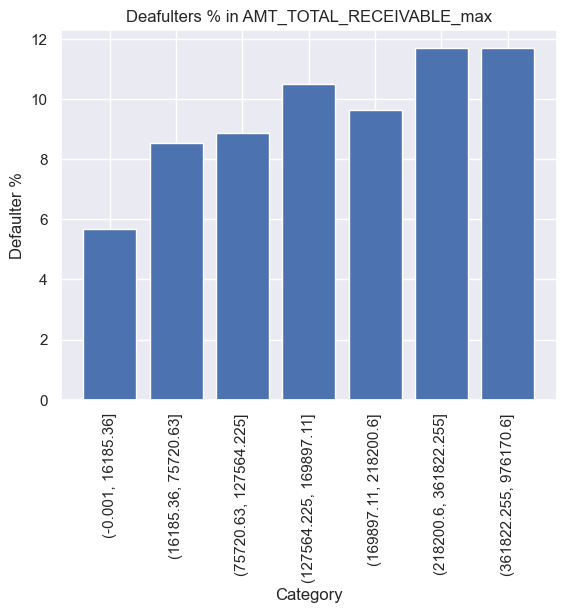

In [99]:
plot_hist_default_pct('AMT_TOTAL_RECEIVABLE_max', good_frame, 9)

### CNT_DRAWINGS_ATM_CURRENT_max

In [100]:
numerical_frame['CNT_DRAWINGS_ATM_CURRENT_max'].isnull().sum()

25765

In [101]:
numerical_frame['CNT_DRAWINGS_ATM_CURRENT_max'].describe()

count    61140.000000
mean         3.995895
std          3.639161
min          0.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         51.000000
Name: CNT_DRAWINGS_ATM_CURRENT_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

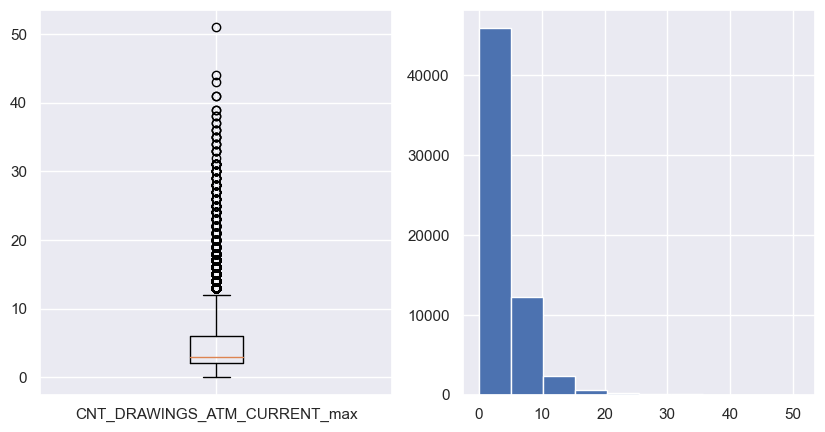

In [102]:
plot_hist_box(numerical_frame, 'CNT_DRAWINGS_ATM_CURRENT_max')

Median of CNT_DRAWINGS_ATM_CURRENT_max with target=0 : 3.000000
Median of CNT_DRAWINGS_ATM_CURRENT_max with target=1 : 4.000000


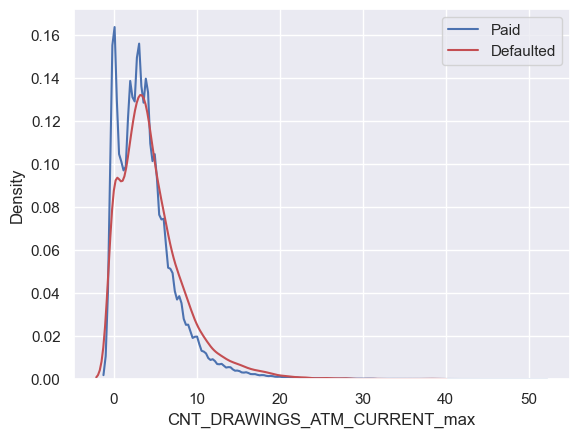

In [103]:
plot_kde_vs_target('CNT_DRAWINGS_ATM_CURRENT_max', numerical_frame)
median_vs_target('CNT_DRAWINGS_ATM_CURRENT_max', numerical_frame)

(-0.001, 1.0]     7.961741
(1.0, 2.0]        8.897708
(2.0, 3.0]        9.470162
(3.0, 4.0]       10.094716
(4.0, 5.0]       10.022120
(5.0, 6.0]       11.345708
(6.0, 8.0]       12.362372
(8.0, 51.0]      14.821183
Name: CNT_DRAWINGS_ATM_CURRENT_max_binned, dtype: float64


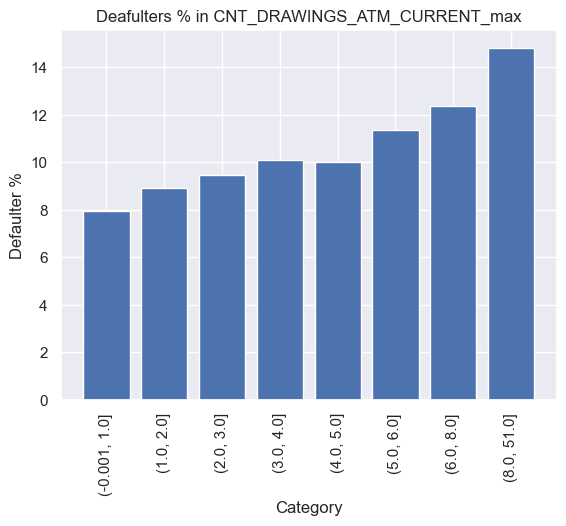

In [104]:
plot_hist_default_pct('CNT_DRAWINGS_ATM_CURRENT_max', numerical_frame, 9)

### CNT_DRAWINGS_CURRENT_max

In [105]:
numerical_frame['CNT_DRAWINGS_CURRENT_max'].isnull().sum()

0

In [106]:
numerical_frame['CNT_DRAWINGS_CURRENT_max'].describe()

count    86905.000000
mean         6.803625
std         10.572428
min          0.000000
25%          0.000000
50%          3.000000
75%          8.000000
max        165.000000
Name: CNT_DRAWINGS_CURRENT_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

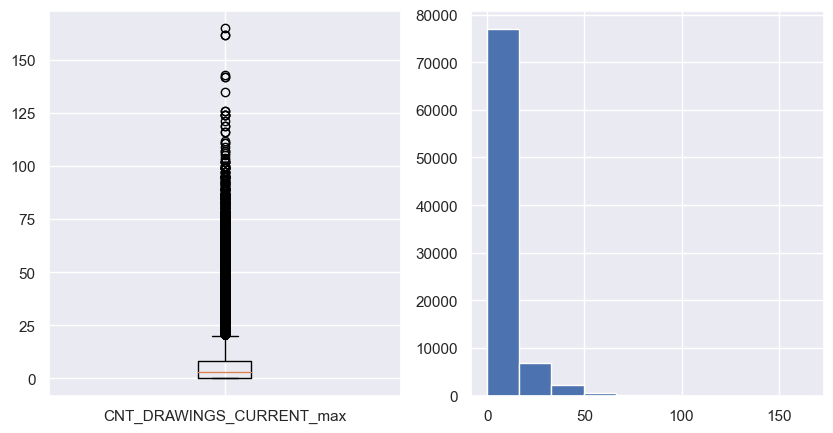

In [107]:
plot_hist_box(numerical_frame, 'CNT_DRAWINGS_CURRENT_max')

Median of CNT_DRAWINGS_CURRENT_max with target=0 : 3.000000
Median of CNT_DRAWINGS_CURRENT_max with target=1 : 6.000000


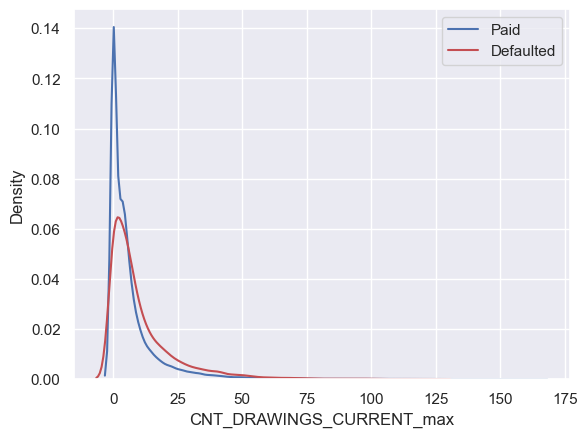

In [108]:
plot_kde_vs_target('CNT_DRAWINGS_CURRENT_max', numerical_frame)
median_vs_target('CNT_DRAWINGS_CURRENT_max', numerical_frame)

(-0.001, 1.0]     5.509946
(1.0, 3.0]        7.378985
(3.0, 4.0]        8.222056
(4.0, 6.0]        8.634223
(6.0, 9.0]       11.042648
(9.0, 17.0]      12.466571
(17.0, 165.0]    15.450972
Name: CNT_DRAWINGS_CURRENT_max_binned, dtype: float64


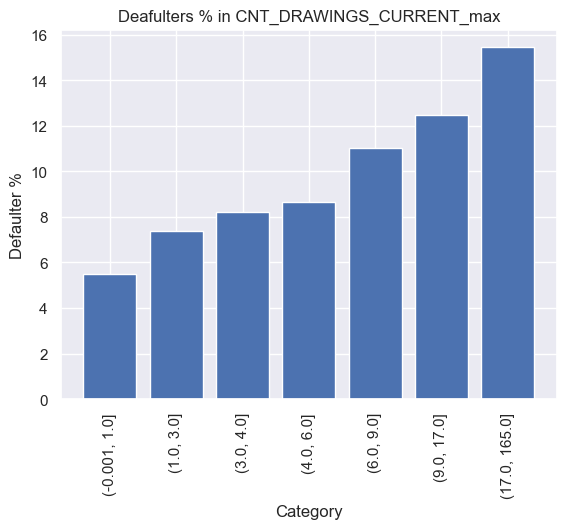

In [109]:
plot_hist_default_pct('CNT_DRAWINGS_CURRENT_max', numerical_frame, 9)

### CNT_INSTALMENT_MATURE_CUM_max

In [110]:
numerical_frame['CNT_INSTALMENT_MATURE_CUM_max'].isnull().sum()

0

In [111]:
numerical_frame['CNT_INSTALMENT_MATURE_CUM_max'].describe()

count    86905.000000
mean        16.287555
std         21.651411
min          0.000000
25%          0.000000
50%          8.000000
75%         23.000000
max        120.000000
Name: CNT_INSTALMENT_MATURE_CUM_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

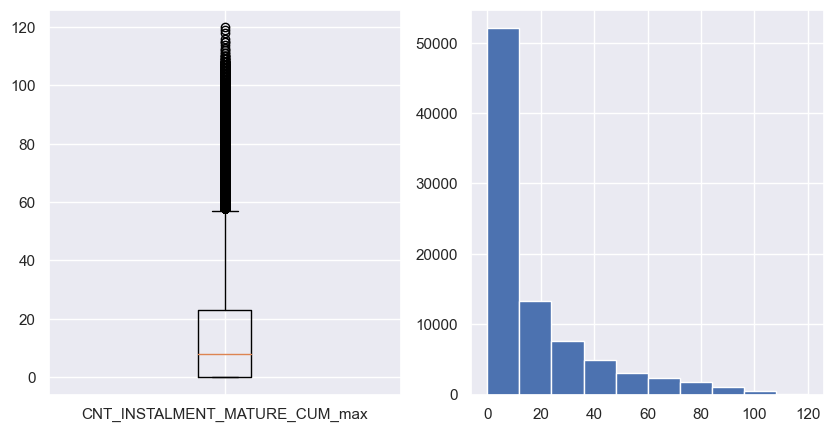

In [112]:
plot_hist_box(numerical_frame, 'CNT_INSTALMENT_MATURE_CUM_max')

Median of CNT_INSTALMENT_MATURE_CUM_max with target=0 : 7.000000
Median of CNT_INSTALMENT_MATURE_CUM_max with target=1 : 8.000000


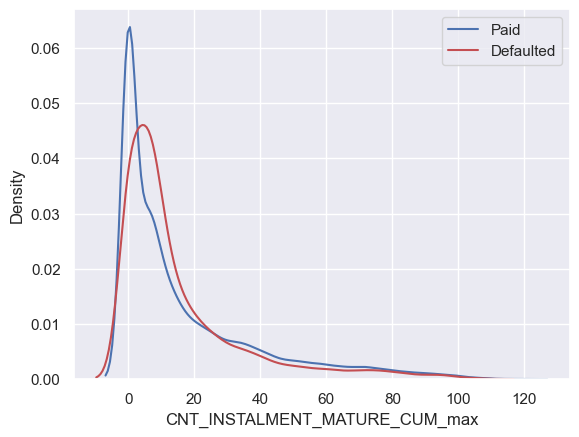

In [113]:
plot_kde_vs_target('CNT_INSTALMENT_MATURE_CUM_max', numerical_frame)
median_vs_target('CNT_INSTALMENT_MATURE_CUM_max', numerical_frame)

(-0.001, 2.0]     5.974505
(2.0, 6.0]       13.767292
(6.0, 9.0]       12.537613
(9.0, 16.0]      10.816653
(16.0, 26.0]      9.317056
(26.0, 45.0]      7.443632
(45.0, 120.0]     6.475651
Name: CNT_INSTALMENT_MATURE_CUM_max_binned, dtype: float64


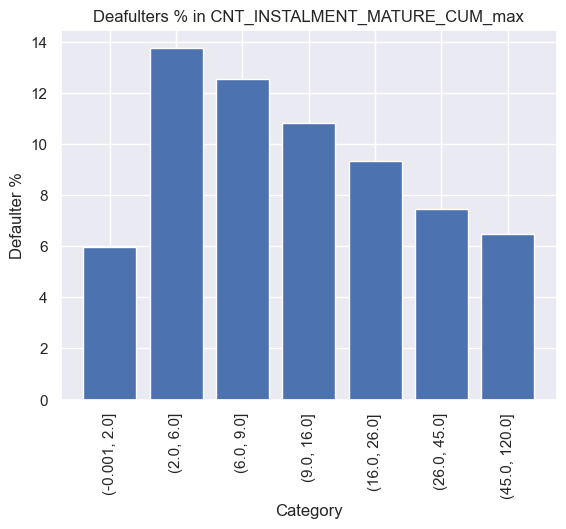

In [114]:
plot_hist_default_pct('CNT_INSTALMENT_MATURE_CUM_max', numerical_frame, 9)

### Dropping Unimportant Variables

In [115]:
numerical_frame.columns.sort_values()

Index(['AMT_BALANCE_max', 'AMT_BALANCE_max_outlier',
       'AMT_DRAWINGS_ATM_CURRENT_max', 'AMT_DRAWINGS_ATM_CURRENT_max_outlier',
       'AMT_DRAWINGS_CURRENT_max', 'AMT_DRAWINGS_CURRENT_max_outlier',
       'AMT_INST_MIN_REGULARITY_max', 'AMT_INST_MIN_REGULARITY_max_outlier',
       'AMT_PAYMENT_CURRENT_median', 'AMT_PAYMENT_CURRENT_median_outlier',
       'AMT_RECEIVABLE_PRINCIPAL_max', 'AMT_RECEIVABLE_PRINCIPAL_max_outlier',
       'AMT_RECIVABLE_max', 'AMT_RECIVABLE_max_outlier',
       'AMT_TOTAL_RECEIVABLE_max', 'AMT_TOTAL_RECEIVABLE_max_outlier',
       'CNT_DRAWINGS_ATM_CURRENT_max', 'CNT_DRAWINGS_CURRENT_max',
       'CNT_INSTALMENT_MATURE_CUM_max', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [117]:
numerical_frame.drop(labels=['AMT_DRAWINGS_ATM_CURRENT_max', 'AMT_DRAWINGS_ATM_CURRENT_max_outlier'],
                     axis=1, inplace=True)

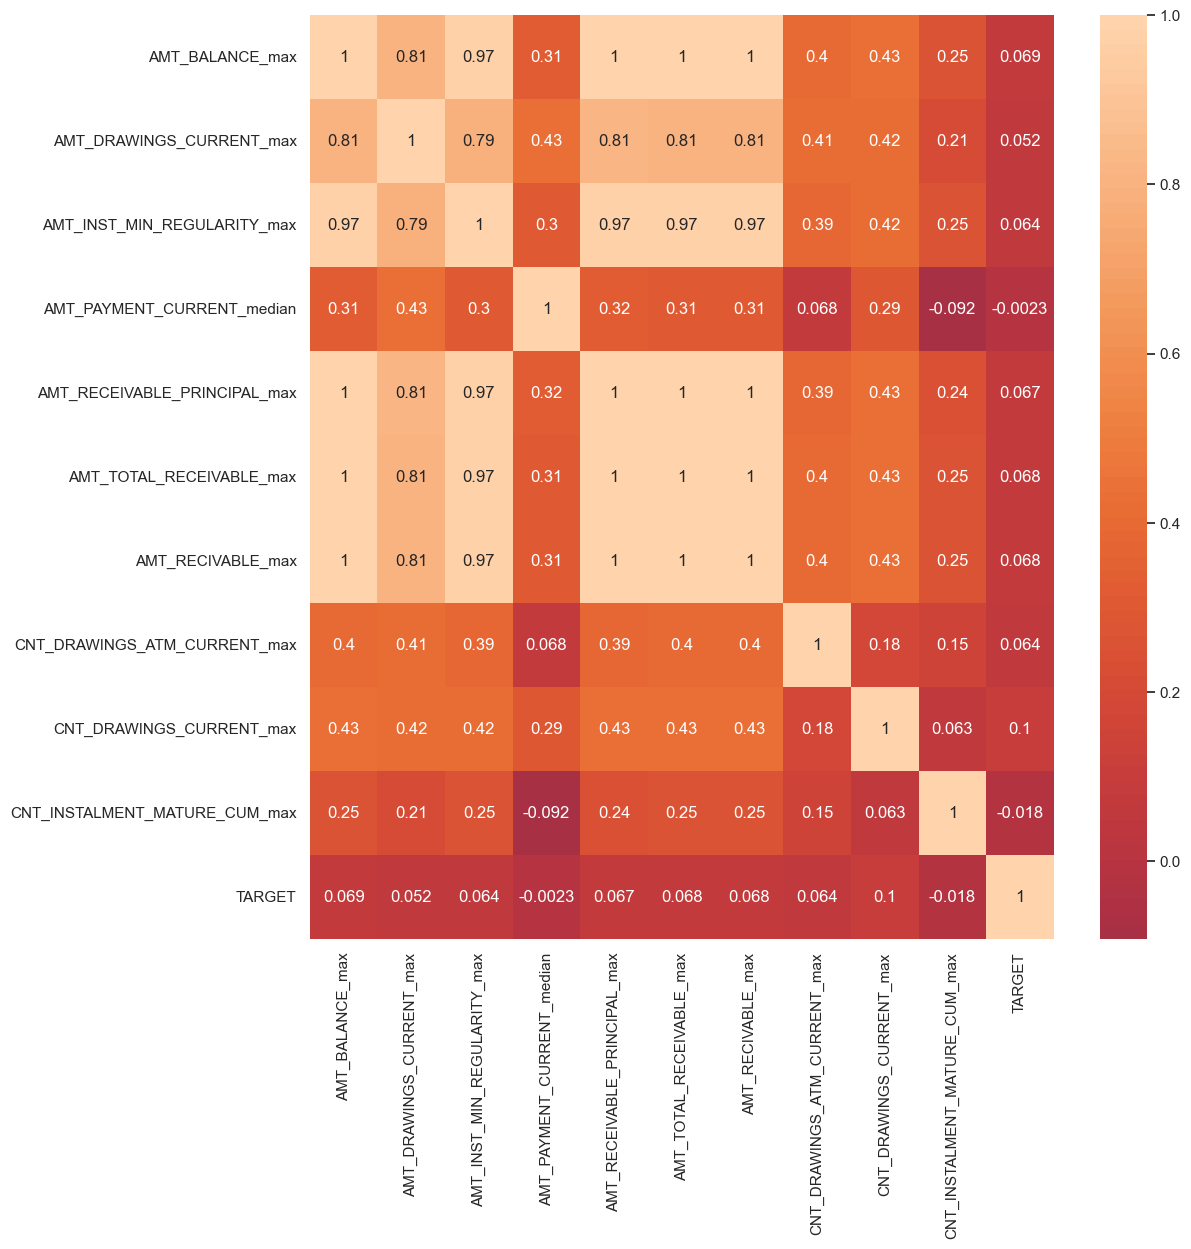

In [118]:
ax=sns.heatmap(numerical_frame.drop(labels=['SK_ID_CURR', 'AMT_BALANCE_max_outlier',
                                            'AMT_DRAWINGS_CURRENT_max_outlier', 'AMT_INST_MIN_REGULARITY_max_outlier',
                                            'AMT_PAYMENT_CURRENT_median_outlier', 'AMT_RECEIVABLE_PRINCIPAL_max_outlier',
                                            'AMT_RECIVABLE_max_outlier', 'AMT_TOTAL_RECEIVABLE_max_outlier'], 
                                    axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=12, h=12)

#### Some more filtering based on correlation

In [119]:
numerical_frame.drop(labels=['AMT_DRAWINGS_CURRENT_max', 'AMT_DRAWINGS_CURRENT_max_outlier',
                             'AMT_INST_MIN_REGULARITY_max', 'AMT_INST_MIN_REGULARITY_max_outlier',
                             'AMT_RECEIVABLE_PRINCIPAL_max', 'AMT_RECEIVABLE_PRINCIPAL_max_outlier',
                             'AMT_RECIVABLE_max', 'AMT_RECIVABLE_max_outlier',
                             'AMT_TOTAL_RECEIVABLE_max', 'AMT_TOTAL_RECEIVABLE_max_outlier'],
                     axis=1, inplace=True)
numerical_frame.columns.sort_values()

Index(['AMT_BALANCE_max', 'AMT_BALANCE_max_outlier',
       'AMT_PAYMENT_CURRENT_median', 'AMT_PAYMENT_CURRENT_median_outlier',
       'CNT_DRAWINGS_ATM_CURRENT_max', 'CNT_DRAWINGS_CURRENT_max',
       'CNT_INSTALMENT_MATURE_CUM_max', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

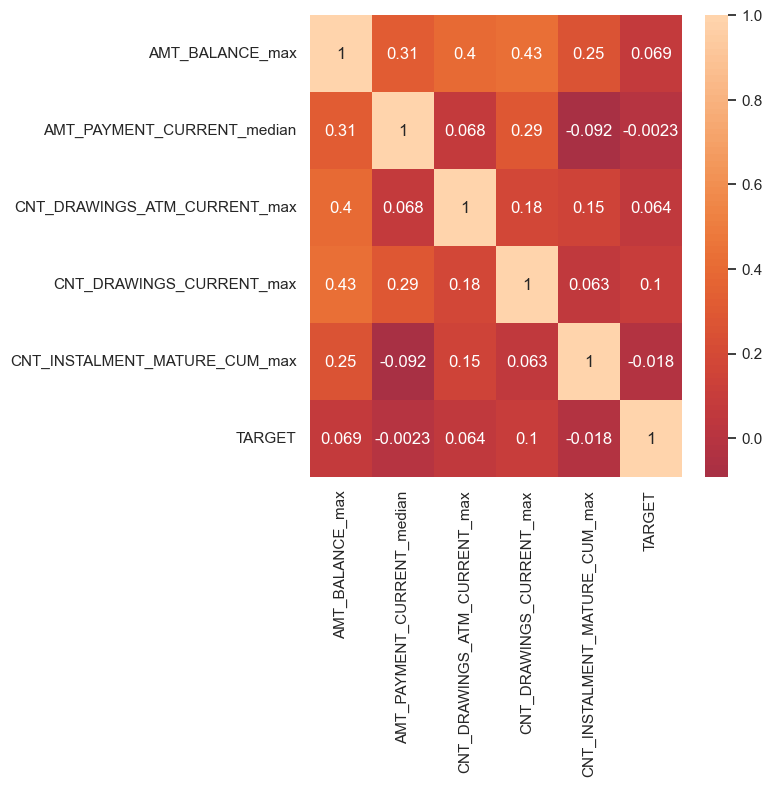

In [122]:
ax=sns.heatmap(numerical_frame.drop(labels=['SK_ID_CURR', 'AMT_BALANCE_max_outlier',
                                            'AMT_PAYMENT_CURRENT_median_outlier'], 
                                    axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=6, h=6)

In [123]:
numerical_frame.to_csv('initial_clean_card.csv', index=False)